# Food Delivery — Python Cohort & Churn Analysis
**Project:** Food Delivery Analytics System  
**Author:** Veer Patel  
**Date:** June 2026

This notebook performs a cohort-based churn analysis on the food delivery database.  
All data is pulled directly from SQL Server using SQLAlchemy.

### Analysis Goals
1. **Churn identification** — Flag customers with no order in 60+ days
2. **Customer segmentation** — Gold / Silver / Bronze tiers by lifetime spend
3. **Tier churn comparison** — Does Bronze churn faster than Gold?
4. **Cohort retention** — Monthly order retention by signup cohort
5. **Recommendations** — Targeted re-engagement campaigns

## Step 1 — Imports and DB Connection

In [14]:
import urllib
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text

# Plotting style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

print('Libraries loaded.')

Libraries loaded.


In [15]:
SERVER   = r'SAGA'           # Change to your SQL Server instance name
DATABASE = 'food_delivery_db'

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True
)

with engine.connect() as conn:
    name = conn.execute(text('SELECT @@SERVERNAME')).scalar()
    print(f'Connected to: {name}')

Connected to: SAGA


## Step 2 — Load Orders Data

In [16]:
query = """
SELECT
    o.order_id,
    o.customer_id,
    c.name         AS customer_name,
    c.city,
    c.signup_date,
    o.order_date,
    o.total_amount,
    o.status,
    o.payment_mode
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.status = 'Delivered'
"""

df = pd.read_sql(query, engine)
df['order_date']  = pd.to_datetime(df['order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

print(f'Loaded {len(df):,} delivered orders')
print(f'Date range: {df["order_date"].min().date()} to {df["order_date"].max().date()}')
df.head(3)

Loaded 39,005 delivered orders
Date range: 2023-01-01 to 2024-12-30


,order_id,customer_id,customer_name,city,signup_date,order_date,total_amount,status,payment_mode
0,1,1,Aryan Maharaj,Hyderabad,2022-11-07,2023-08-20 21:02:28,504.80,Delivered,UPI
1,3,1,Aryan Maharaj,Hyderabad,2022-11-07,2023-05-09 20:50:13,1248.27,Delivered,Cash
2,4,1,Aryan Maharaj,Hyderabad,2022-11-07,2023-08-07 20:10:20,1471.65,Delivered,UPI


## Step 3 — Customer-Level Aggregation

In [17]:
ANALYSIS_DATE = df['order_date'].max()   # Use last order date as 'today'
print(f'Analysis snapshot date: {ANALYSIS_DATE.date()}')

customer_stats = (
    df.groupby(['customer_id', 'customer_name', 'city', 'signup_date'])
    .agg(
        total_orders   = ('order_id',     'count'),
        total_spend    = ('total_amount',  'sum'),
        avg_order_val  = ('total_amount',  'mean'),
        first_order    = ('order_date',    'min'),
        last_order     = ('order_date',    'max')
    )
    .reset_index()
)

customer_stats['days_since_last_order'] = (
    (ANALYSIS_DATE - customer_stats['last_order']).dt.days
)

print(f'Total active customers (with at least 1 delivered order): {len(customer_stats):,}')
customer_stats.head(3)

Analysis snapshot date: 2024-12-30
Total active customers (with at least 1 delivered order): 1,000


,customer_id,customer_name,city,signup_date,total_orders,total_spend,avg_order_val,first_order,last_order,days_since_last_order
0,1,Aryan Maharaj,Hyderabad,2022-11-07,34,26877.44,790.512941,2023-01-01 11:04:08,2024-12-16 11:51:09,14
1,2,Rushil Saini,Chennai,2022-03-27,28,22143.42,790.836429,2023-01-27 20:39:15,2024-10-11 21:09:05,80
2,3,Hemangini Lalla,Mumbai,2022-08-20,28,25962.93,927.247500,2023-01-03 17:18:52,2024-12-28 18:21:47,2


## Step 4 — Churn Identification (60-Day Rule)

A customer is defined as **churned** if they have not placed any delivered order in the last 60 days.

In [18]:
customer_stats['is_churned'] = customer_stats['days_since_last_order'] > 60

total_customers = len(customer_stats)
churned         = customer_stats['is_churned'].sum()
churn_rate      = churned / total_customers * 100

print(f'Total customers analyzed : {total_customers:,}')
print(f'Churned (60+ days silent): {churned:,}')
print(f'Churn rate               : {churn_rate:.1f}%')

churned_stats = customer_stats[customer_stats['is_churned']]
print(f'\nAmong churned customers:')
print(f'  Avg days since last order : {churned_stats["days_since_last_order"].mean():.0f} days')
print(f'  Avg lifetime spend        : ₹{churned_stats["total_spend"].mean():,.0f}')
print(f'  Avg orders placed         : {churned_stats["total_orders"].mean():.1f}')

Total customers analyzed : 1,000
Churned (60+ days silent): 247
Churn rate               : 24.7%

Among churned customers:
  Avg days since last order : 156 days
  Avg lifetime spend        : ₹18,288
  Avg orders placed         : 22.1


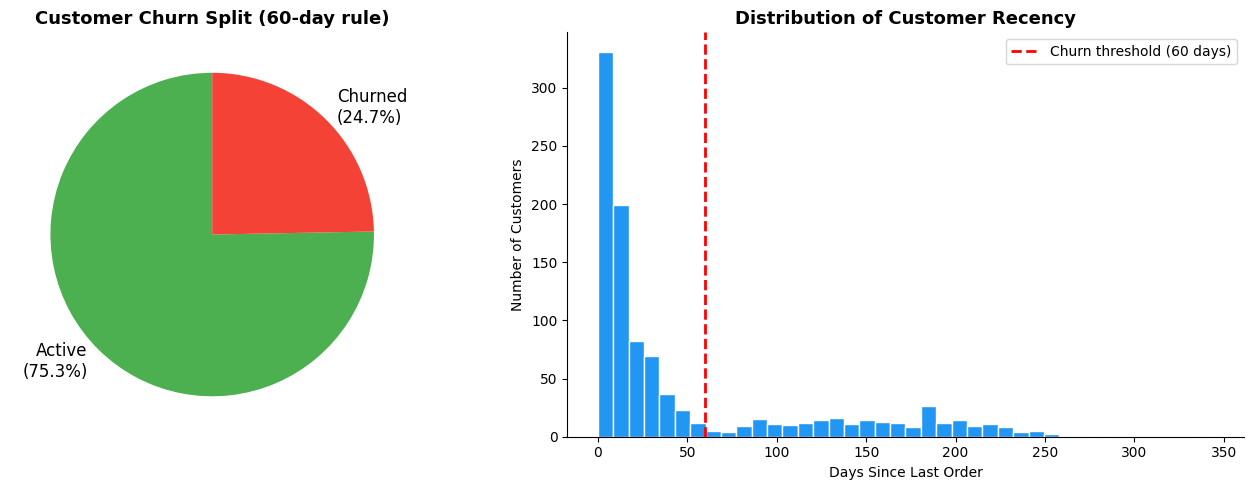

Figure saved: churn_overview.png


In [19]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
labels = [f'Active\n({100-churn_rate:.1f}%)', f'Churned\n({churn_rate:.1f}%)']
axes[0].pie([total_customers-churned, churned], labels=labels,
            colors=['#4CAF50', '#F44336'], startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Customer Churn Split (60-day rule)', fontsize=13, fontweight='bold')

# Days since last order histogram
axes[1].hist(customer_stats['days_since_last_order'], bins=40, color='#2196F3', edgecolor='white')
axes[1].axvline(60, color='red', linestyle='--', linewidth=2, label='Churn threshold (60 days)')
axes[1].set_xlabel('Days Since Last Order')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Distribution of Customer Recency', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: churn_overview.png')

## Step 5 — Customer Segmentation (Gold / Silver / Bronze)

Customers are segmented into 3 equal-size tiers using `pd.qcut()` on lifetime spend:
- **Gold** — top 33% by total spend
- **Silver** — middle 33%
- **Bronze** — bottom 33%

In [20]:
customer_stats['segment'] = pd.qcut(
    customer_stats['total_spend'],
    q=3,
    labels=['Bronze', 'Silver', 'Gold']
)

segment_summary = (
    customer_stats
    .groupby('segment', observed=True)
    .agg(
        customers     = ('customer_id',    'count'),
        avg_spend     = ('total_spend',    'mean'),
        avg_orders    = ('total_orders',   'mean'),
        churn_count   = ('is_churned',     'sum'),
        churn_rate_pct= ('is_churned',     lambda x: x.mean()*100)
    )
    .reset_index()
)

segment_summary['avg_spend']      = segment_summary['avg_spend'].round(0)
segment_summary['avg_orders']     = segment_summary['avg_orders'].round(1)
segment_summary['churn_rate_pct'] = segment_summary['churn_rate_pct'].round(1)

print('Customer Segment Summary:')
print(segment_summary.to_string(index=False))

# Bronze vs Gold churn ratio
gold_churn   = segment_summary[segment_summary['segment']=='Gold']['churn_rate_pct'].values[0]
bronze_churn = segment_summary[segment_summary['segment']=='Bronze']['churn_rate_pct'].values[0]
ratio        = bronze_churn / gold_churn
print(f'\nBronze churn rate : {bronze_churn:.1f}%')
print(f'Gold churn rate   : {gold_churn:.1f}%')
print(f'Bronze churn is {ratio:.1f}x the rate of Gold customers')

Customer Segment Summary:
segment  customers  avg_spend  avg_orders  churn_count  churn_rate_pct
 Bronze        334    19778.0        24.5          234            70.1
 Silver        333    32598.0        39.4           10             3.0
   Gold        333    44504.0        53.2            3             0.9

Bronze churn rate : 70.1%
Gold churn rate   : 0.9%
Bronze churn is 77.9x the rate of Gold customers


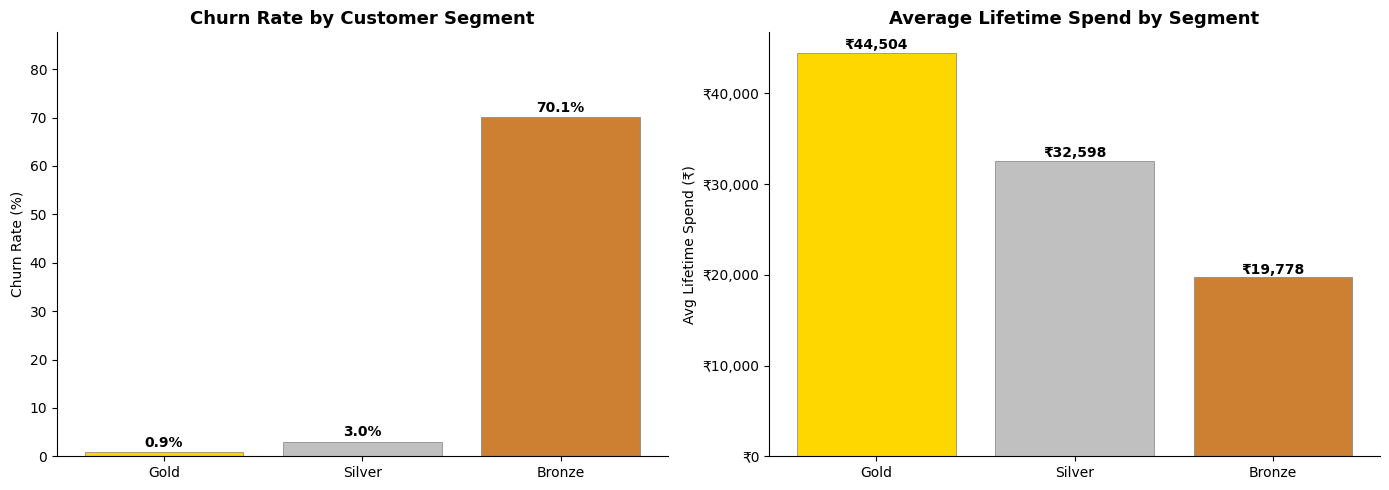

Figure saved: segment_churn.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Gold': '#FFD700', 'Silver': '#C0C0C0', 'Bronze': '#CD7F32'}
segs   = ['Gold', 'Silver', 'Bronze']
seg_colors = [colors[s] for s in segs]

# Churn rate by segment
rates = [segment_summary[segment_summary['segment']==s]['churn_rate_pct'].values[0] for s in segs]
bars  = axes[0].bar(segs, rates, color=seg_colors, edgecolor='grey', linewidth=0.5)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Customer Segment', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(rates)*1.25)

# Avg spend by segment
spends = [segment_summary[segment_summary['segment']==s]['avg_spend'].values[0] for s in segs]
bars2  = axes[1].bar(segs, spends, color=seg_colors, edgecolor='grey', linewidth=0.5)
for bar, spend in zip(bars2, spends):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'₹{spend:,.0f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Avg Lifetime Spend (₹)')
axes[1].set_title('Average Lifetime Spend by Segment', fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.tight_layout()
plt.savefig('segment_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: segment_churn.png')

## Step 6 — Monthly Cohort Retention Analysis

A cohort is defined by the **month of the customer's first order**. Retention is tracked month-by-month to see what share of the cohort continues placing orders.

In [22]:
# Build cohort month and order month
df2 = df.copy()
df2['order_month']  = df2['order_date'].dt.to_period('M')
first_orders        = df2.groupby('customer_id')['order_month'].min().rename('cohort_month')
df2                 = df2.join(first_orders, on='customer_id')

df2['cohort_index'] = (
    (df2['order_month'].astype(int) - df2['cohort_month'].astype(int))
)

# Cohort pivot
cohort_data = (
    df2.groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

cohort_size      = cohort_pivot[0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)

# Keep only first 12 months
retention_matrix = retention_matrix.iloc[:, :12]

print('Cohort retention matrix (first 6 months shown):')
print((retention_matrix.iloc[:6, :7] * 100).round(1).to_string())

Cohort retention matrix (first 6 months shown):
cohort_index      0      1      2      3      4      5     6
cohort_month                                                
2023-01       100.0   77.6   81.8   80.2   80.4   78.5  81.7
2023-02       100.0   77.8   80.4   79.1   73.9   75.2  82.4
2023-03       100.0   77.1   68.6   68.6   77.1   71.4  68.6
2023-04       100.0   69.2   69.2   46.2   69.2   76.9  69.2
2023-05       100.0    NaN    NaN    NaN  100.0  100.0   NaN
2023-06       100.0  100.0  100.0  100.0  100.0  100.0   NaN


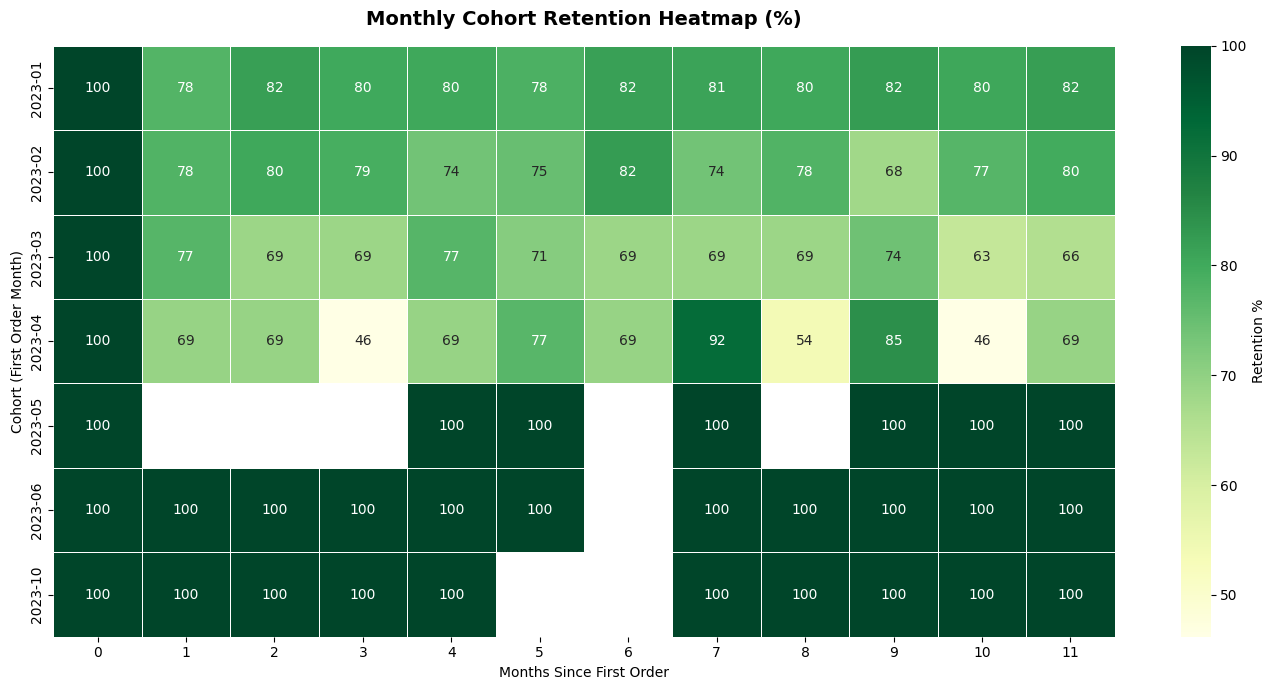

Figure saved: cohort_retention.png


In [23]:
fig, ax = plt.subplots(figsize=(14, 7))

# Convert period index to string for display
ret_display = retention_matrix.copy()
ret_display.index = ret_display.index.astype(str)

sns.heatmap(
    ret_display * 100,
    annot=True, fmt='.0f', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Retention %'},
    ax=ax
)

ax.set_title('Monthly Cohort Retention Heatmap (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Order')
ax.set_ylabel('Cohort (First Order Month)')

plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: cohort_retention.png')

## Step 7 — High-Value Churned Customers (Re-engagement Targets)

In [24]:
high_value_threshold = customer_stats['total_spend'].quantile(0.75)

re_engagement_targets = (
    customer_stats[
        (customer_stats['is_churned'])  &
        (customer_stats['total_spend'] >= high_value_threshold)
    ]
    [['customer_id','customer_name','city','total_orders','total_spend',
      'days_since_last_order','segment']]
    .sort_values('total_spend', ascending=False)
)

print(f'High-value threshold : ₹{high_value_threshold:,.0f} (75th percentile)')
print(f'Re-engagement targets: {len(re_engagement_targets):,} churned high-value customers')
print(f'Avg spend of targets : ₹{re_engagement_targets["total_spend"].mean():,.0f}')
print(f'\nTop 10 targets:')
re_engagement_targets.head(10)

High-value threshold : ₹41,143 (75th percentile)
Re-engagement targets: 1 churned high-value customers
Avg spend of targets : ₹42,751

Top 10 targets:


,customer_id,customer_name,city,total_orders,total_spend,days_since_last_order,segment
13,14,Chandresh Zachariah,Hyderabad,47,42751.18,70,Gold


## Step 8 — Churn by City

Churn rate by city:
     city  customers  churned  churn_rate_pct
Bangalore         87       27       31.034483
  Kolkata         62       17       27.419355
   Mumbai        255       65       25.490196
Hyderabad         90       22       24.444444
    Delhi        292       71       24.315068
     Pune         73       16       21.917808
  Chennai         64       14       21.875000
Ahmedabad         77       15       19.480519


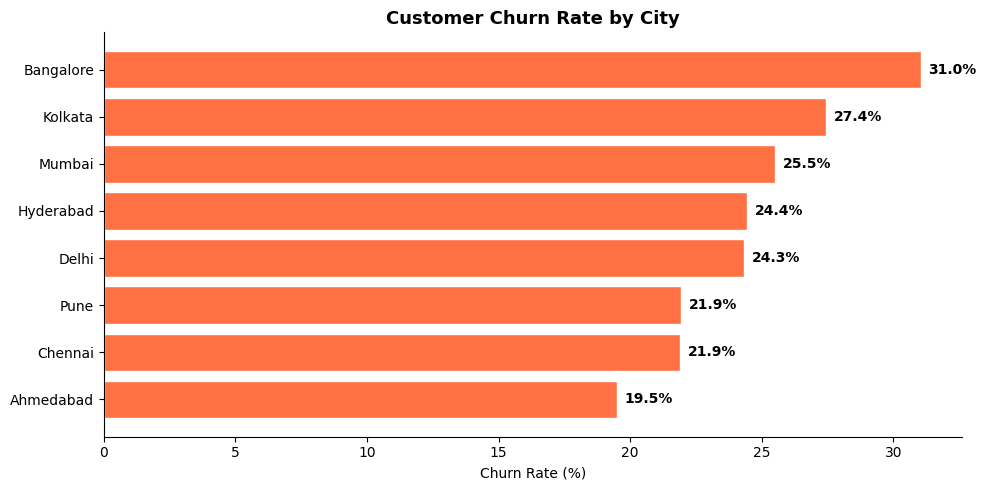

In [25]:
city_churn = (
    customer_stats
    .groupby('city')
    .agg(
        customers      = ('customer_id',    'count'),
        churned        = ('is_churned',     'sum'),
        churn_rate_pct = ('is_churned',     lambda x: x.mean()*100)
    )
    .sort_values('churn_rate_pct', ascending=False)
    .reset_index()
)

print('Churn rate by city:')
print(city_churn.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(city_churn['city'], city_churn['churn_rate_pct'],
               color='#FF7043', edgecolor='white')
for bar, rate in zip(bars, city_churn['churn_rate_pct']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Customer Churn Rate by City', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('churn_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Summary and Recommendations

In [26]:
print('=' * 60)
print('COHORT ANALYSIS — KEY FINDINGS')
print('=' * 60)
print(f'\n1. CHURN RATE')
print(f'   {churn_rate:.1f}% of customers have churned (no order in 60+ days)')
print(f'   = {churned:,} out of {total_customers:,} active customers')

print(f'\n2. TIER CHURN DISPARITY')
print(f'   Bronze churn rate : {bronze_churn:.1f}%')
print(f'   Gold churn rate   : {gold_churn:.1f}%')
print(f'   => Bronze customers churn at {ratio:.1f}x the rate of Gold customers')

print(f'\n3. RE-ENGAGEMENT OPPORTUNITY')
print(f'   {len(re_engagement_targets):,} high-value churned customers identified')
print(f'   Avg lifetime spend: ₹{re_engagement_targets["total_spend"].mean():,.0f}')
print(f'   Potential GMV recovery with 20% win-back rate:')
print(f'   ₹{re_engagement_targets["total_spend"].mean() * 0.2 * len(re_engagement_targets):,.0f}')

print(f'\n4. RECOMMENDATIONS')
print('   a) Launch targeted discount vouchers (15–20%) for high-value churned customers')
print('   b) Bronze tier: introduce a loyalty points program to increase engagement')
print('   c) Push notifications at 45-day inactivity mark (before churn threshold)')
print('   d) City-specific campaigns for cities with highest churn rates')
print('=' * 60)

COHORT ANALYSIS — KEY FINDINGS

1. CHURN RATE
   24.7% of customers have churned (no order in 60+ days)
   = 247 out of 1,000 active customers

2. TIER CHURN DISPARITY
   Bronze churn rate : 70.1%
   Gold churn rate   : 0.9%
   => Bronze customers churn at 77.9x the rate of Gold customers

3. RE-ENGAGEMENT OPPORTUNITY
   1 high-value churned customers identified
   Avg lifetime spend: ₹42,751
   Potential GMV recovery with 20% win-back rate:
   ₹8,550

4. RECOMMENDATIONS
   a) Launch targeted discount vouchers (15–20%) for high-value churned customers
   b) Bronze tier: introduce a loyalty points program to increase engagement
   c) Push notifications at 45-day inactivity mark (before churn threshold)
   d) City-specific campaigns for cities with highest churn rates
